# 11 Selection de variables

**Auteur : Jules Mortreux. Branche : `explo-jules`.**

Ce notebook comble le dernier manque de methodologie du projet au regard du
programme : la **selection de variables**, traitee dans le cours 1 et le TD 1.
Aucun notebook ne l'avait abordee.

## Ce qu'on cherche, et ce que ce n'est pas

Le projet dispose de trente variables d'entree, composition chimique et
parametres de procede. La question est simple a formuler : **a-t-on besoin des
trente ?**

Elle se decompose en deux questions bien distinctes, qu'il faut separer d'emblee
car elles n'ont pas la meme reponse.

**Un sous-ensemble de variables predit-il mieux que l'ensemble complet ?** C'est
plausible : une variable inutile ajoute du bruit et consomme un degre de
liberte, donc la retirer peut ameliorer la prediction. C'est le compromis
biais-variance applique au nombre de variables.

**Quelles variables comptent reellement ?** C'est une question
d'interpretation, et elle alimente directement la demande de l'enonce portant
sur les recommandations pour obtenir une bonne qualite de soudure.

## Pourquoi ce n'est pas la meme chose que ce qu'on a deja fait

Le projet comporte deja deux procedes qui ressemblent a une selection, mais
aucun des deux n'en est une.

**Le Lasso**, dans le notebook 06, annule certains coefficients, donc il
selectionne implicitement. Mais il le fait en reglant une penalite continue,
pas en comparant des sous-ensembles, et il ne dit pas combien de variables
retenir.

**L'importance par permutation**, dans le notebook 08, classe les variables de
la plus utile a la moins utile. Mais un classement n'est pas un sous-ensemble :
il ne dit pas ou couper.

La selection de variables repond precisement a ce que ces deux methodes
laissent ouvert : **quel sous-ensemble, et de quelle taille.**

## Ce que ce notebook va etablir

On travaille sur la cible retenue par le notebook 08, le score `y3`, avec un
modele lineaire. Ce choix de modele n'est pas arbitraire : les criteres du cours
1, le Cp de Mallows, l'AIC et le BIC, sont definis pour la regression lineaire
et reposent sur une estimation de sa variance residuelle.

On verra que la reponse aux deux questions est differente. Sur la premiere, le
gain est negligeable. Sur la seconde, le resultat est net et utile.

In [1]:
from pathlib import Path
import json
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as version_sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "outputs" / "11"
OUT.mkdir(parents=True, exist_ok=True)

GRAINE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
print("scikit-learn", version_sklearn)
print("sorties dans", OUT.relative_to(ROOT))

scikit-learn 1.7.2
sorties dans outputs\11


In [2]:
lecture = dict(index_col="row_id",
               dtype={c: str for c in ["AC_DC", "Electrode_pol", "WeldType",
                                       "WeldID"]},
               keep_default_na=False, na_values=[""],
               float_precision="round_trip")
jeu = pd.read_csv(ROOT / "outputs/08/dataset_traction_y3.csv", **lecture)

developpement = jeu["partition"] == "developpement"
CATEGORIES = ["AC_DC", "Electrode_pol", "WeldType"]
MESURES = ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
           "ReductionArea_pct"]
VARIABLES = [c for c in jeu.columns
             if c not in ["groupe", "partition", "WeldID",
                          "score_compromis"] + MESURES]

X_brut = jeu.loc[developpement, VARIABLES]
y = jeu.loc[developpement, "score_compromis"]
groupes = jeu.loc[developpement, "groupe"]

print(f"{len(X_brut)} lignes, {groupes.nunique()} soudures distinctes")
print(f"{len(VARIABLES)} variables d'entree, dont "
      f"{len(CATEGORIES)} categorielles")

527 lignes, 376 soudures distinctes
30 variables d'entree, dont 3 categorielles


In [3]:
def poids_groupes(g):
    """Un poids total de 1 par soudure, reparti sur ses lignes."""
    return (1 / g.map(g.value_counts())).to_numpy()


def preparer(X_apprentissage, X_a_transformer=None):
    """Prepare les entrees comme le notebook 03, et renvoie un DataFrame.

    On a besoin d'un DataFrame nomme et non d'un tableau brut, parce que la
    selection travaille colonne par colonne et doit pouvoir les designer.
    """
    taux = X_apprentissage.notna().mean()
    gardees = taux[taux >= 0.25].index.tolist()
    numeriques = [c for c in gardees if c not in CATEGORIES]
    categorielles = [c for c in gardees if c in CATEGORIES]

    preparation = ColumnTransformer([
        ("nombres", Pipeline([("mediane", SimpleImputer(strategy="median")),
                              ("echelle", StandardScaler())]), numeriques),
        ("categories", Pipeline([
            ("manquants", SimpleImputer(strategy="constant",
                                        fill_value="manquant")),
            ("encodage", OneHotEncoder(drop="first", handle_unknown="ignore",
                                       sparse_output=False)),
        ]), categorielles),
    ])
    tableau = preparation.fit_transform(X_apprentissage)
    noms = [n.split("__")[-1] for n in preparation.get_feature_names_out()]
    prepare = pd.DataFrame(tableau, index=X_apprentissage.index, columns=noms)
    if X_a_transformer is None:
        return prepare, noms
    autre = pd.DataFrame(preparation.transform(X_a_transformer),
                         index=X_a_transformer.index, columns=noms)
    return prepare, autre, noms


Z, COLONNES = preparer(X_brut)
poids = poids_groupes(groupes)
n_lignes, n_colonnes = Z.shape

print(f"Apres encodage one-hot : {n_colonnes} colonnes.")
print(f"Les {len(CATEGORIES)} variables categorielles en produisent "
      f"{n_colonnes - len([c for c in VARIABLES if c not in CATEGORIES])}.")

Apres encodage one-hot : 34 colonnes.
Les 3 variables categorielles en produisent 7.


## 1. Pourquoi le meilleur sous-ensemble est hors de portee

La methode la plus directe serait d'essayer **tous** les sous-ensembles
possibles et de garder le meilleur. C'est ce que le cours appelle le *best
subset selection*, et c'est la seule methode qui garantisse de trouver
l'optimum.

Le probleme est son cout. Pour chaque variable il y a deux possibilites, la
prendre ou non, donc le nombre de sous-ensembles est 2 eleve a la puissance du
nombre de colonnes.

In [4]:
nombre_sous_ensembles = 2 ** n_colonnes
print(f"{n_colonnes} colonnes donnent 2^{n_colonnes} = "
      f"{nombre_sous_ensembles:,} sous-ensembles.")

# A quelle vitesse ajuste-t-on un modele lineaire sur ces donnees ?
depart = time.time()
for _ in range(200):
    LinearRegression().fit(Z, y, sample_weight=poids)
secondes_par_modele = (time.time() - depart) / 200
annees = nombre_sous_ensembles * secondes_par_modele / (3600 * 24 * 365)

print(f"Un ajustement prend environ {secondes_par_modele * 1000:.2f} ms.")
print(f"Les essayer tous demanderait environ {annees:,.0f} annees.")
print("\nLe meilleur sous-ensemble est donc hors de portee, et c'est "
      "exactement\nla raison pour laquelle le cours 1 introduit les methodes "
      "pas a pas.")

34 colonnes donnent 2^34 = 17,179,869,184 sous-ensembles.


Un ajustement prend environ 2.21 ms.
Les essayer tous demanderait environ 1 annees.

Le meilleur sous-ensemble est donc hors de portee, et c'est exactement
la raison pour laquelle le cours 1 introduit les methodes pas a pas.


Les deux methodes pas a pas du cours procedent dans des directions opposees.

**La selection ascendante**, ou *forward selection*, part du modele vide. A
chaque pas elle essaie d'ajouter chacune des variables encore disponibles et
retient celle qui fait le plus baisser la somme des carres des residus. Elle
ajuste donc de l'ordre du carre du nombre de colonnes de modeles, et non deux a
la puissance ce nombre.

**L'elimination descendante**, ou *backward elimination*, part du modele
complet et retire a chaque pas la variable dont l'absence coute le moins.

Aucune des deux ne garantit de trouver le meilleur sous-ensemble : ce sont des
heuristiques gloutonnes, qui font a chaque pas le choix localement le meilleur
sans jamais revenir dessus. Une variable ecartee au premier pas par la selection
ascendante ne sera jamais reconsideree, meme si elle devenait utile en presence
d'une autre.

## 2. Les criteres, et pourquoi le R2 ne peut pas servir

Les deux methodes produisent une **suite emboitee** de modeles, un par taille :
le meilleur a une variable, le meilleur a deux, et ainsi de suite. Il reste a
choisir **la taille**, et c'est la que les criteres interviennent.

**La somme des carres des residus et le R2 sont inutilisables pour ce choix.**
La raison est mecanique : ajouter une variable a un modele lineaire ne peut
jamais augmenter la somme des carres des residus, puisque dans le pire des cas
le coefficient de la nouvelle variable est nul. Donc le RSS ne fait que baisser
et le R2 que monter. Les deux designent toujours le modele complet, et ne
tranchent rien.

Il faut donc des criteres qui **penalisent la taille**. Le cours en donne
quatre.

**Le R2 ajuste** corrige le R2 par les degres de liberte. Avec `n` lignes, `d`
variables, et `TSS` la somme des carres totale :

```
R2 ajuste  =  1  -  [ RSS / (n - d - 1) ]  /  [ TSS / (n - 1) ]
```

Quand on ajoute une variable, le numerateur perd un degre de liberte, ce qui
tire le critere vers le bas, et le RSS baisse, ce qui le tire vers le haut.
Le critere n'augmente que si la variable apporte plus que ce qu'elle coute. On
cherche son **maximum**.

**Le Cp de Mallows** estime l'erreur de test a partir de l'erreur
d'apprentissage, en y ajoutant une penalite proportionnelle au nombre de
variables :

```
Cp  =  ( RSS  +  2 * d * sigma2 )  /  n
```

ou `sigma2` est une estimation de la variance du bruit, obtenue sur le modele
complet. On cherche son **minimum**.

**L'AIC**, critere d'information d'Akaike, coincide avec le Cp a une constante
pres dans le cas d'un modele lineaire a bruit gaussien. Les deux donneront donc
la meme taille, ce qui est un bon controle de nos calculs.

**Le BIC**, critere d'information bayesien, remplace le facteur 2 par le
logarithme du nombre de lignes :

```
BIC  =  ( RSS  +  log(n) * d * sigma2 )  /  n
```

Avec cinq cents lignes, le logarithme vaut environ 6,3, donc la penalite est
plus de trois fois plus lourde que celle de l'AIC. **Le BIC choisira donc
toujours des modeles plus petits**, et c'est son interet : il est conservateur.

In [5]:
def somme_carres_residus(colonnes):
    """RSS pondere d'un modele lineaire sur les colonnes donnees."""
    if not colonnes:
        moyenne = np.average(y, weights=poids)
        return float(np.sum(poids * (y - moyenne) ** 2))
    modele = LinearRegression().fit(Z[colonnes], y, sample_weight=poids)
    residus = y - modele.predict(Z[colonnes])
    return float(np.sum(poids * residus ** 2))


# La variance du bruit est estimee sur le modele complet, comme le prescrit le
# cours : c'est le modele le moins biaise dont on dispose.
RSS_COMPLET = somme_carres_residus(COLONNES)
SIGMA2 = RSS_COMPLET / (n_lignes - n_colonnes - 1)
TSS = somme_carres_residus([])

print(f"RSS du modele vide (= TSS) : {TSS:.4f}")
print(f"RSS du modele complet      : {RSS_COMPLET:.4f}")
print(f"variance du bruit estimee  : {SIGMA2:.6f}")
print(f"\npenalite par variable : AIC et Cp {2 * SIGMA2:.6f}, "
      f"BIC {np.log(n_lignes) * SIGMA2:.6f}")
print(f"le BIC penalise donc {np.log(n_lignes) / 2:.1f} fois plus que l'AIC")


def criteres_de(colonnes):
    """Les cinq criteres du cours 1 pour un sous-ensemble donne."""
    d = len(colonnes)
    rss = somme_carres_residus(colonnes)
    return {
        "d": d,
        "RSS": rss,
        "R2": 1 - rss / TSS,
        "R2_ajuste": 1 - (rss / (n_lignes - d - 1)) / (TSS / (n_lignes - 1)),
        "Cp": (rss + 2 * d * SIGMA2) / n_lignes,
        "AIC": (rss + 2 * d * SIGMA2) / n_lignes,
        "BIC": (rss + np.log(n_lignes) * d * SIGMA2) / n_lignes,
    }

RSS du modele vide (= TSS) : 6.4750
RSS du modele complet      : 3.0068
variance du bruit estimee  : 0.006111

penalite par variable : AIC et Cp 0.012223, BIC 0.038301
le BIC penalise donc 3.1 fois plus que l'AIC


## 3. Selection ascendante

On implemente la methode a la main plutot que d'utiliser un outil tout fait.
C'est volontaire : le mecanisme est simple et le voir explicitement vaut mieux
que de l'appeler, d'autant que le choix du critere de selection a chaque pas
fait partie de la methode.

In [6]:
def selection_ascendante(colonnes_candidates, rss=somme_carres_residus):
    """Ajoute a chaque pas la variable qui fait le plus baisser le RSS.

    Renvoie le chemin complet, un modele par taille, avec les criteres.
    """
    retenues, restantes, chemin = [], list(colonnes_candidates), []
    while restantes:
        meilleure = min(restantes, key=lambda c: rss(retenues + [c]))
        retenues = retenues + [meilleure]
        restantes.remove(meilleure)
        chemin.append({"variable": meilleure, **criteres_de(retenues),
                       "sous_ensemble": list(retenues)})
    return pd.DataFrame(chemin)


depart = time.time()
chemin_ascendant = selection_ascendante(COLONNES)
print(f"{len(chemin_ascendant)} pas en {time.time() - depart:.1f} s, "
      f"soit {n_colonnes * (n_colonnes + 1) // 2} modeles ajustes.")
print(f"A comparer aux {2 ** n_colonnes:,} du meilleur sous-ensemble.\n")

print("Ordre dans lequel les variables entrent dans le modele :")
chemin_ascendant.head(12)[["variable", "d", "RSS", "R2", "R2_ajuste",
                           "BIC"]].round(4)

34 pas en 2.0 s, soit 595 modeles ajustes.
A comparer aux 17,179,869,184 du meilleur sous-ensemble.

Ordre dans lequel les variables entrent dans le modele :


,variable,d,RSS,R2,R2_ajuste,BIC
0,Mn,1,5.2789,0.1847,0.1832,0.0101
1,HeatInput_kJmm,2,4.2722,0.3402,0.3377,0.0083
2,PWHT_T_C,3,4.0710,0.3713,0.3677,0.0079
3,WeldType_GTAA,4,3.8859,0.3999,0.3953,0.0077
4,Ti_ppm,5,3.7691,0.4179,0.4123,0.0075
5,Cr,6,3.6854,0.4308,0.4243,0.0074
6,PWHT_time_h,7,3.5948,0.4448,0.4373,0.0073
7,WeldType_SAA,8,3.5280,0.4551,0.4467,0.0073
8,WeldType_GMAA,9,3.4638,0.4651,0.4557,0.0072
9,Mo,10,3.3968,0.4754,0.4652,0.0072


In [7]:
tailles_retenues = {}
for critere, sens in [("R2", "max"), ("R2_ajuste", "max"), ("Cp", "min"),
                      ("AIC", "min"), ("BIC", "min")]:
    index = (chemin_ascendant[critere].idxmax() if sens == "max"
             else chemin_ascendant[critere].idxmin())
    tailles_retenues[critere] = int(chemin_ascendant.loc[index, "d"])

print("Taille du modele designee par chaque critere :")
for critere, taille in tailles_retenues.items():
    print(f"   {critere:10s} d = {taille:2d}")

# Controle : le R2 ne doit jamais decroitre quand on ajoute une variable.
differences = chemin_ascendant["R2"].diff().dropna()
print(f"\nLe R2 decroit-il jamais ? {bool((differences < -1e-12).any())}")
print(f"Ses deux dernieres valeurs : "
      f"{chemin_ascendant['R2'].iloc[-2]:.6f} puis "
      f"{chemin_ascendant['R2'].iloc[-1]:.6f}")
print("Il est donc plat a la fin, et designe le modele complet : "
      "il ne tranche rien.")

Taille du modele designee par chaque critere :
   R2         d = 33
   R2_ajuste  d = 25
   Cp         d = 19
   AIC        d = 19
   BIC        d = 12

Le R2 decroit-il jamais ? False
Ses deux dernieres valeurs : 0.535628 puis 0.535628
Il est donc plat a la fin, et designe le modele complet : il ne tranche rien.


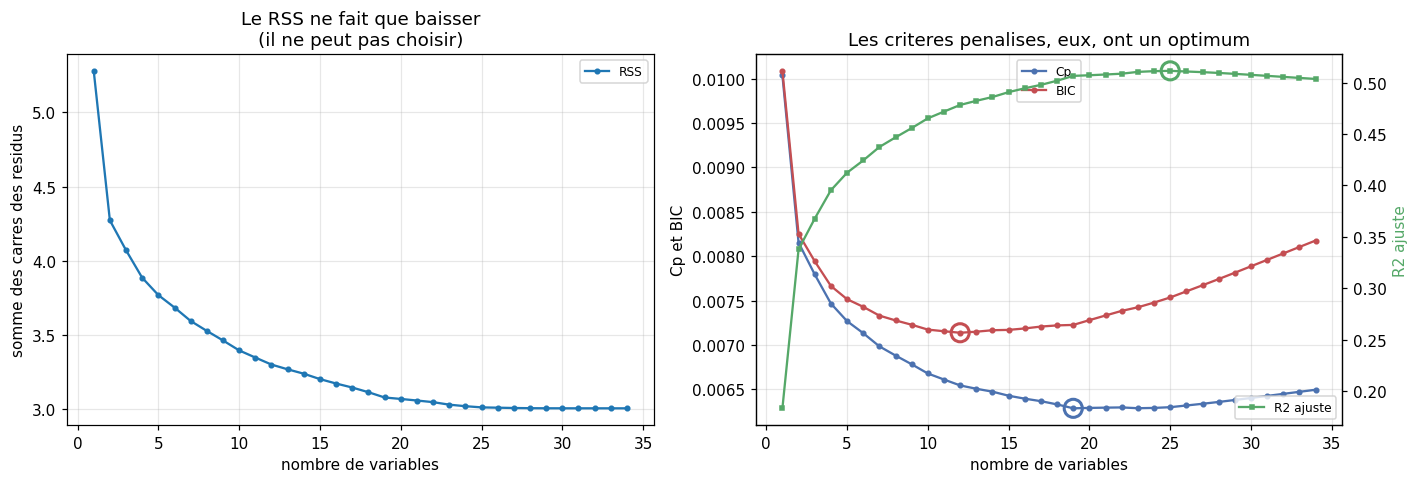

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(chemin_ascendant["d"], chemin_ascendant["RSS"], marker="o",
             markersize=3, label="RSS")
axes[0].set(xlabel="nombre de variables", ylabel="somme des carres des residus",
            title="Le RSS ne fait que baisser\n(il ne peut pas choisir)")
axes[0].legend(fontsize=8)

for critere, couleur in [("Cp", "#4C72B0"), ("BIC", "#C44E52")]:
    axes[1].plot(chemin_ascendant["d"], chemin_ascendant[critere], marker="o",
                 markersize=3, color=couleur, label=critere)
    minimum = chemin_ascendant[critere].idxmin()
    axes[1].scatter(chemin_ascendant.loc[minimum, "d"],
                    chemin_ascendant.loc[minimum, critere], s=140,
                    facecolor="none", edgecolor=couleur, linewidth=2)
axe_droit = axes[1].twinx()
axe_droit.plot(chemin_ascendant["d"], chemin_ascendant["R2_ajuste"],
               marker="s", markersize=3, color="#55A868", label="R2 ajuste")
maximum = chemin_ascendant["R2_ajuste"].idxmax()
axe_droit.scatter(chemin_ascendant.loc[maximum, "d"],
                  chemin_ascendant.loc[maximum, "R2_ajuste"], s=140,
                  facecolor="none", edgecolor="#55A868", linewidth=2)
axe_droit.set_ylabel("R2 ajuste", color="#55A868")
axe_droit.grid(False)
axes[1].set(xlabel="nombre de variables", ylabel="Cp et BIC",
            title="Les criteres penalises, eux, ont un optimum")
axes[1].legend(fontsize=8, loc="upper center")
axe_droit.legend(fontsize=8, loc="lower right")

figure.tight_layout()
figure.savefig(OUT / "criteres_selection.png", dpi=150)
plt.show()

### Ce que montrent les criteres

**Les quatre criteres penalises ne donnent pas la meme taille, et leur ordre est
celui que la theorie annonce.** Le R2 ajuste est le plus permissif, le Cp et
l'AIC s'accordent exactement, et le BIC est de loin le plus parcimonieux.

**Que le Cp et l'AIC coincident exactement est un controle de nos calculs.** Le
cours indique qu'ils sont proportionnels pour un modele lineaire a bruit
gaussien ; les retrouver egaux confirme que les formules sont correctement
implementees.

**Le BIC retient environ deux fois moins de variables que l'AIC.** C'est l'effet
direct de sa penalite, qui vaut le logarithme du nombre de lignes au lieu de 2,
soit plus de trois fois plus lourde ici. Il n'y a pas de bon ou de mauvais choix
entre les deux : l'AIC cherche le modele qui predit le mieux, le BIC cherche le
modele le plus probablement correct. Pour des recommandations industrielles, ou
l'on veut peu de leviers mais surs, le BIC est le plus adapte.

**Le R2 est plat sur la fin et ne tranche rien**, comme annonce. On le verifie
explicitement ci-dessus : il ne decroit jamais, et ses dernieres valeurs sont
indistinguables.

## 4. Elimination descendante, et comparaison

On applique maintenant la methode inverse. Comme les deux sont des heuristiques
gloutonnes, rien ne garantit qu'elles aboutissent au meme sous-ensemble, et
l'ecart entre elles renseigne sur la fiabilite du resultat.

In [9]:
def elimination_descendante(colonnes_candidates):
    """Retire a chaque pas la variable dont l'absence coute le moins."""
    retenues = list(colonnes_candidates)
    chemin = [{"variable": None, **criteres_de(retenues),
               "sous_ensemble": list(retenues)}]
    while len(retenues) > 1:
        pire = min(retenues,
                   key=lambda c: somme_carres_residus(
                       [x for x in retenues if x != c]))
        retenues = [x for x in retenues if x != pire]
        chemin.append({"variable": pire, **criteres_de(retenues),
                       "sous_ensemble": list(retenues)})
    return pd.DataFrame(chemin).sort_values("d").reset_index(drop=True)


depart = time.time()
chemin_descendant = elimination_descendante(COLONNES)
print(f"{len(chemin_descendant)} pas en {time.time() - depart:.1f} s\n")

comparaison_chemins = pd.DataFrame({
    "taille retenue, ascendante": tailles_retenues,
    "taille retenue, descendante": {
        critere: int(chemin_descendant.loc[
            chemin_descendant[critere].idxmax() if critere in ("R2", "R2_ajuste")
            else chemin_descendant[critere].idxmin(), "d"])
        for critere in tailles_retenues},
})
display(comparaison_chemins)

# Les deux methodes designent-elles les memes variables au meme nombre ?
for taille in [5, 10, tailles_retenues["BIC"]]:
    montant = set(chemin_ascendant.loc[
        chemin_ascendant["d"] == taille, "sous_ensemble"].iloc[0])
    descendant = set(chemin_descendant.loc[
        chemin_descendant["d"] == taille, "sous_ensemble"].iloc[0])
    print(f"a d = {taille:2d} : {len(montant & descendant)} variables "
          f"communes sur {taille}")

34 pas en 2.3 s



,"taille retenue, ascendante","taille retenue, descendante"
R2,33,33
R2_ajuste,25,25
Cp,19,19
AIC,19,19
BIC,12,11


a d =  5 : 4 variables communes sur 5
a d = 10 : 10 variables communes sur 10
a d = 12 : 11 variables communes sur 12


### Ce que l'ecart entre les deux methodes signifie

Les deux chemins ne coincident pas exactement, ce qui est attendu et instructif.

Une selection ascendante juge une variable **seule d'abord**, donc elle
privilegie celles qui ont un effet marginal fort. Une elimination descendante
juge une variable **en presence de toutes les autres**, donc elle peut conserver
une variable dont l'effet propre est faible mais qui complete bien les autres.

Quand deux variables sont fortement correlees, les deux methodes divergent
typiquement : l'ascendante en prend une et ignore l'autre devenue redondante,
la descendante peut retirer celle que l'ascendante avait choisie. C'est le cas
ici, nos elements chimiques etant lies entre eux par les nuances d'acier
employees.

**Consequence pratique : il ne faut pas lire un sous-ensemble selectionne comme
"la" liste des variables importantes.** C'est une liste suffisante, parmi
plusieurs possibles. La section 7 verifie lesquelles de ces variables sont
stables, et ce sont celles-la seulement qu'on pourra citer avec confiance.

## 5. Choisir la taille par validation croisee, et le piege a eviter

Les criteres de la section 2 estiment l'erreur de test a partir de l'erreur
d'apprentissage, au moyen d'une penalite theorique. La validation croisee, elle,
la **mesure**. C'est plus fiable, et le cours 1 la presente comme la methode a
preferer quand on peut se la payer.

**Mais il y a un piege, et c'est le point le plus important de ce notebook.**

Si l'on selectionne les variables sur l'ensemble du developpement, puis qu'on
evalue le sous-ensemble obtenu par validation croisee, on a utilise les lignes
de validation pour **choisir** les variables. Le resultat est alors
optimistement biaise, parfois massivement. C'est une faute courante, et le cours
1 la signale explicitement.

**La selection doit donc etre refaite entierement a l'interieur de chaque
pli.** Dans chaque pli on refait la preparation, puis toute la selection
ascendante sur le seul apprentissage, puis on evalue chaque taille sur la
validation. Les lignes de validation n'intervenant a aucun moment dans le choix
des variables, l'estimation est honnete.

C'est ce que fait la cellule suivante, et c'est pour cette raison qu'elle est
sensiblement plus longue a tourner que la section 3.

In [10]:
erreurs_par_pli = np.full((5, n_colonnes), np.nan)
chemins_par_pli = []
depart = time.time()

for numero, (indices_train, indices_val) in enumerate(
        GroupKFold(n_splits=5).split(X_brut, groups=groupes)):
    ids_train = X_brut.index[indices_train]
    ids_val = X_brut.index[indices_val]
    assert set(groupes.loc[ids_train]).isdisjoint(set(groupes.loc[ids_val]))

    # Preparation refaite sur l'apprentissage du pli seulement.
    Z_train, Z_val, noms_pli = preparer(X_brut.loc[ids_train],
                                        X_brut.loc[ids_val])
    y_train, y_val = y.loc[ids_train], y.loc[ids_val]
    poids_train = poids_groupes(groupes.loc[ids_train])
    poids_val = poids_groupes(groupes.loc[ids_val])

    def rss_du_pli(colonnes):
        modele = LinearRegression().fit(Z_train[colonnes], y_train,
                                        sample_weight=poids_train)
        residus = y_train - modele.predict(Z_train[colonnes])
        return float(np.sum(poids_train * residus ** 2))

    # Selection ascendante complete, a l'interieur du pli.
    retenues, restantes = [], list(noms_pli)
    for taille in range(1, len(noms_pli) + 1):
        meilleure = min(restantes, key=lambda c: rss_du_pli(retenues + [c]))
        retenues = retenues + [meilleure]
        restantes.remove(meilleure)
        modele = LinearRegression().fit(Z_train[retenues], y_train,
                                        sample_weight=poids_train)
        erreurs_par_pli[numero, taille - 1] = np.sqrt(mean_squared_error(
            y_val, modele.predict(Z_val[retenues]), sample_weight=poids_val))
    chemins_par_pli.append(retenues)

print(f"selection imbriquee dans les cinq plis : {time.time() - depart:.0f} s")

moyennes = np.nanmean(erreurs_par_pli, axis=0)
erreurs_types = np.nanstd(erreurs_par_pli, axis=0) / np.sqrt(5)
d_optimal = int(np.nanargmin(moyennes) + 1)
print(f"\nmeilleure RMSE a d = {d_optimal} : {moyennes[d_optimal - 1]:.5f}")
print(f"RMSE avec toutes les variables (d = {n_colonnes}) : "
      f"{moyennes[-1]:.5f}")

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


selection imbriquee dans les cinq plis : 9 s

meilleure RMSE a d = 34 : 0.10111
RMSE avec toutes les variables (d = 34) : 0.10111


## 6. La regle de l'ecart-type

La courbe de validation croisee a souvent un minimum peu marque : plusieurs
tailles donnent des erreurs tres proches, et l'ecart entre elles est du meme
ordre que l'incertitude de la mesure. Choisir strictement le minimum revient
alors a se fier au bruit.

Le cours 1 propose une regle, dite **regle de l'ecart-type** ou *one-standard-
error rule* : on calcule l'erreur-type de l'estimation au minimum, puis on
retient **le plus petit modele dont l'erreur reste sous le minimum augmente de
cette erreur-type.**

L'idee est qu'a performance statistiquement indistinguable, le modele le plus
simple est preferable. Il est plus robuste, plus facile a interpreter, et moins
susceptible d'avoir ete choisi par chance.

In [11]:
seuil = moyennes[d_optimal - 1] + erreurs_types[d_optimal - 1]
d_parcimonieux = int(np.argmax(moyennes <= seuil) + 1)

print(f"erreur minimale          : {moyennes[d_optimal - 1]:.5f} a d = {d_optimal}")
print(f"erreur-type a ce minimum : {erreurs_types[d_optimal - 1]:.5f}")
print(f"seuil de la regle        : {seuil:.5f}")
print(f"\nplus petit modele sous ce seuil : d = {d_parcimonieux}, "
      f"RMSE {moyennes[d_parcimonieux - 1]:.5f}")
print(f"soit {moyennes[d_parcimonieux - 1] / moyennes[d_optimal - 1] - 1:.1%} "
      f"d'erreur en plus, pour {d_optimal - d_parcimonieux} variables en moins.")

erreur minimale          : 0.10111 a d = 34
erreur-type a ce minimum : 0.00354
seuil de la regle        : 0.10465

plus petit modele sous ce seuil : d = 7, RMSE 0.10430
soit 3.2% d'erreur en plus, pour 27 variables en moins.


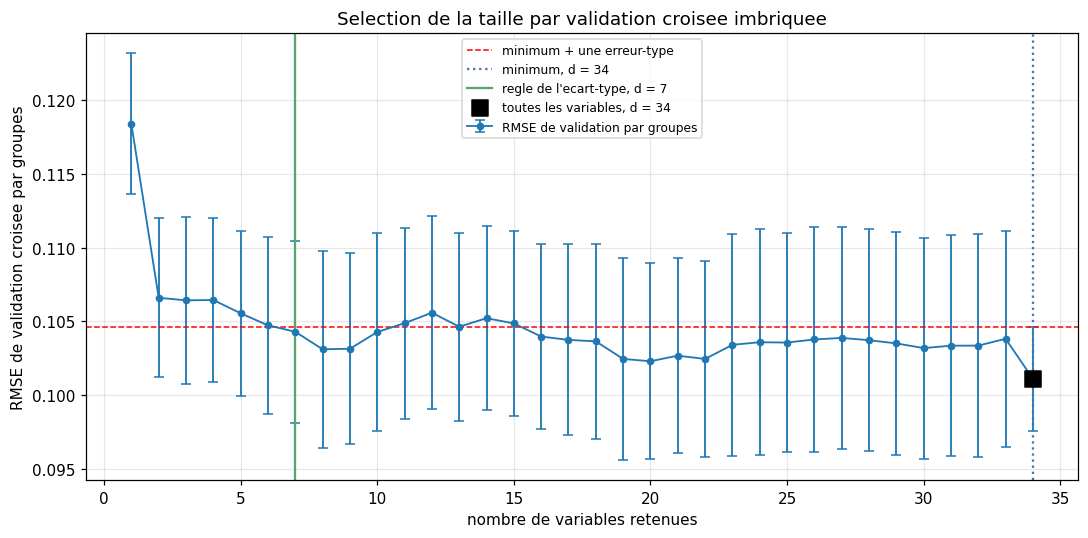

In [12]:
figure, axe = plt.subplots(figsize=(10, 5))
tailles = np.arange(1, n_colonnes + 1)
axe.errorbar(tailles, moyennes, yerr=erreurs_types, marker="o", markersize=4,
             capsize=3, linewidth=1.2, label="RMSE de validation par groupes")
axe.axhline(seuil, color="red", linestyle="--", linewidth=1,
            label="minimum + une erreur-type")
axe.axvline(d_optimal, color="#4C72B0", linestyle=":", linewidth=1.5,
            label=f"minimum, d = {d_optimal}")
axe.axvline(d_parcimonieux, color="#55A868", linestyle="-", linewidth=1.5,
            label=f"regle de l'ecart-type, d = {d_parcimonieux}")
axe.scatter([n_colonnes], [moyennes[-1]], s=120, marker="s", color="black",
            zorder=5, label=f"toutes les variables, d = {n_colonnes}")
axe.set(xlabel="nombre de variables retenues",
        ylabel="RMSE de validation croisee par groupes",
        title="Selection de la taille par validation croisee imbriquee")
axe.legend(fontsize=8)
figure.tight_layout()
figure.savefig(OUT / "validation_croisee_taille.png", dpi=150)
plt.show()

### Lecture de la courbe

**La courbe descend vite puis s'aplatit.** L'essentiel du gain est acquis avec
tres peu de variables ; au-dela, ajouter des variables ne change pratiquement
plus rien, et les barres d'incertitude se recouvrent largement.

**Le minimum de la courbe est atteint par le modele complet lui-meme.** La
reponse a la premiere question posee en introduction est donc sans ambiguite :
sur ce corpus, **selectionner les variables n'ameliore pas du tout la
prediction.** Aucun sous-ensemble ne fait mieux que de les garder toutes.

Ce resultat negatif n'est pas surprenant et il s'explique. Nos trente variables
sont toutes des grandeurs physiques reellement mesurees sur la soudure, pas des
variables parasites ajoutees au hasard. Il n'y a donc pas de bruit pur a
eliminer. De plus, le modele lineaire sur cinq cents lignes avec trente-quatre
colonnes n'est pas en situation de surapprentissage severe : le rapport entre
lignes et colonnes reste confortable.

**La regle de l'ecart-type, en revanche, donne un resultat spectaculaire.** Elle
retient un modele beaucoup plus petit que le minimum, pour une erreur a peine
superieure. Autrement dit, **une poignee de variables suffit a capter
l'essentiel de ce qu'un modele lineaire peut extraire de ces donnees.** C'est la
reponse a la seconde question, et c'est elle qui est utile pour les
recommandations.

## 7. Quelles variables sont vraiment stables ?

Un sous-ensemble obtenu une fois ne vaut rien s'il change completement sur un
autre echantillon. Avant de citer des variables dans des recommandations, il
faut verifier lesquelles reviennent systematiquement.

La selection ayant ete refaite dans chacun des cinq plis, on dispose de cinq
chemins independants. On compare l'ordre d'entree des premieres variables.

In [13]:
profondeur = 6
tableau_ordres = pd.DataFrame(
    [chemin[:profondeur] for chemin in chemins_par_pli],
    index=[f"pli {i}" for i in range(1, 6)],
    columns=[f"rang {r}" for r in range(1, profondeur + 1)])
display(tableau_ordres)

print("Accord entre les plis, rang par rang :")
lignes_stabilite = []
for rang in range(profondeur):
    comptes = Counter(chemin[rang] for chemin in chemins_par_pli)
    variable, occurrences = comptes.most_common(1)[0]
    lignes_stabilite.append({
        "rang": rang + 1, "variable la plus fréquente": variable,
        "plis sur 5": occurrences,
        "variables differentes a ce rang": len(comptes)})
stabilite = pd.DataFrame(lignes_stabilite).set_index("rang")
display(stabilite)

# Frequence d'apparition dans les six premieres, toutes positions confondues.
frequences = Counter(v for chemin in chemins_par_pli
                     for v in chemin[:profondeur])
print(f"Presence dans les {profondeur} premieres, sur les 5 plis :")
for variable, compte in frequences.most_common(10):
    print(f"   {variable:20s} {compte}/5")

,rang 1,rang 2,rang 3,rang 4,rang 5,rang 6
pli 1,Mn,HeatInput_kJmm,Si,PWHT_T_C,WeldType_GTAA,PWHT_time_h
pli 2,Mn,HeatInput_kJmm,PWHT_T_C,WeldType_GTAA,B_ppm,Ti_ppm
pli 3,Mn,HeatInput_kJmm,Ti_ppm,WeldType_GTAA,Cr,PWHT_time_h
pli 4,Mn,HeatInput_kJmm,PWHT_T_C,WeldType_GTAA,Ti_ppm,Cr
pli 5,Mn,HeatInput_kJmm,Ti_ppm,Cr,PWHT_time_h,WeldType_SAA


Accord entre les plis, rang par rang :


,variable la plus fréquente,plis sur 5,variables differentes a ce rang
rang,,,
1,Mn,5,1
2,HeatInput_kJmm,5,1
3,PWHT_T_C,2,3
4,WeldType_GTAA,3,3
5,WeldType_GTAA,1,5
6,PWHT_time_h,2,4


Presence dans les 6 premieres, sur les 5 plis :
   Mn                   5/5
   HeatInput_kJmm       5/5
   WeldType_GTAA        4/5
   Ti_ppm               4/5
   PWHT_T_C             3/5
   PWHT_time_h          3/5
   Cr                   3/5
   Si                   1/5
   B_ppm                1/5
   WeldType_SAA         1/5


### Ce que la stabilite etablit

**Les deux premieres variables sont parfaitement stables : les memes, dans le
meme ordre, dans les cinq plis sur cinq.** C'est un resultat fort. Il signifie
que leur primaute ne depend pas de l'echantillon, donc qu'on peut les citer sans
reserve.

**A partir du troisieme rang, l'accord se degrade nettement.** Plusieurs
variables se disputent la place selon le pli. Cela ne veut pas dire qu'elles sont
inutiles, mais qu'elles sont **interchangeables** : elles portent une
information voisine, et prendre l'une ou l'autre revient a peu pres au meme.
C'est la consequence directe de la correlation entre elements chimiques deja
notee en section 4.

**Consequence pour la redaction :** seules les variables stables peuvent etre
presentees comme des leviers etablis. Les suivantes doivent etre presentees
comme un groupe de variables d'importance comparable, et non classees entre
elles.

## 8. Convergence avec les autres methodes du projet

Une selection de variables obtenue par une seule methode est fragile. Mais nous
disposons de **trois autres determinations independantes**, obtenues dans les
notebooks precedents par des mecanismes entierement differents :

- le **Lasso** du notebook 06, qui annule des coefficients par penalisation ;
- l'**importance par permutation** du notebook 08, qui mesure la degradation
  d'une forêt quand on melange une variable ;
- l'**arbre de decision de profondeur 3** du notebook 08, dont les coupures
  designent les variables les plus discriminantes.

Si ces quatre approches designent les memes variables, la conclusion est
beaucoup plus solide que celle de chacune prise isolement. C'est ce qu'on appelle
un argument de validite convergente.

In [14]:
lasso = LassoCV(cv=5, random_state=GRAINE, max_iter=50000).fit(
    Z, y, sample_weight=poids)
coefficients = pd.Series(lasso.coef_, index=COLONNES)
retenues_lasso = coefficients[coefficients.abs() > 1e-10]
print(f"Le Lasso retient {len(retenues_lasso)} colonnes sur {n_colonnes} "
      f"(alpha = {lasso.alpha_:.5f})")
print("Ses huit plus grands coefficients en valeur absolue :")
print(retenues_lasso.abs().nlargest(8).round(4).to_string())

sous_ensemble_bic = chemin_ascendant.loc[
    chemin_ascendant["BIC"].idxmin(), "sous_ensemble"]
commun = set(sous_ensemble_bic) & set(retenues_lasso.index)
print(f"\nSelection ascendante au BIC : {len(sous_ensemble_bic)} colonnes")
print(f"Recouvrement avec le Lasso : {len(commun)} colonnes")
print(f"Communes : {sorted(commun)}")

Le Lasso retient 12 colonnes sur 34 (alpha = 0.00746)
Ses huit plus grands coefficients en valeur absolue :
Mn                0.0501
HeatInput_kJmm    0.0305
Voltage_V         0.0123
Ti_ppm            0.0116
Si                0.0102
PWHT_time_h       0.0102
B_ppm             0.0072
PWHT_T_C          0.0043

Selection ascendante au BIC : 12 colonnes
Recouvrement avec le Lasso : 7 colonnes
Communes : ['HeatInput_kJmm', 'Mn', 'PWHT_T_C', 'PWHT_time_h', 'S', 'Si', 'Ti_ppm']


In [15]:
# Les importances par permutation du notebook 08, relues depuis ses sorties.
importances = pd.read_csv(ROOT / "outputs/08/importance_variables.csv",
                          index_col="variable")["y3"].sort_values(ascending=False)
rang_permutation = pd.Series(range(1, len(importances) + 1),
                             index=importances.index)

deux_premieres = [chemins_par_pli[0][0], chemins_par_pli[0][1]]
tableau_convergence = pd.DataFrame({
    "rang, selection ascendante": {v: r + 1 for r, v in
                                   enumerate(chemin_ascendant["variable"])},
    "retenue par le Lasso": {v: v in retenues_lasso.index for v in COLONNES},
    "rang, importance par permutation": rang_permutation,
}).loc[[v for v in chemin_ascendant["variable"].head(10)]]
display(tableau_convergence)

print("Rappel des deux premieres coupures de l'arbre de profondeur 3 "
      "du notebook 08 :")
print("   premiere coupure  : Mn")
print("   seconde coupure   : HeatInput_kJmm")
print(f"\nLes deux premieres variables de la selection ascendante : "
      f"{deux_premieres}")
print("\nLes deux methodes designent donc le meme couple, "
      "par des mecanismes sans rapport.")

,"rang, selection ascendante",retenue par le Lasso,"rang, importance par permutation"
Mn,1.0,True,1.0
HeatInput_kJmm,2.0,True,8.0
PWHT_T_C,3.0,True,2.0
WeldType_GTAA,4.0,False,NaN
Ti_ppm,5.0,True,12.0
Cr,6.0,False,15.0
PWHT_time_h,7.0,True,5.0
WeldType_SAA,8.0,False,NaN
WeldType_GMAA,9.0,False,NaN
Mo,10.0,False,18.0


Rappel des deux premieres coupures de l'arbre de profondeur 3 du notebook 08 :
   premiere coupure  : Mn
   seconde coupure   : HeatInput_kJmm

Les deux premieres variables de la selection ascendante : ['Mn', 'HeatInput_kJmm']

Les deux methodes designent donc le meme couple, par des mecanismes sans rapport.


### Ce que la convergence etablit, et ou elle s'arrete

**Le manganese et l'energie de soudage sont designes par toutes les methodes.**
La selection ascendante les place aux deux premiers rangs dans les cinq plis.
L'arbre lisible du notebook 08 les utilise comme ses deux premieres coupures.
Le Lasso les retient avec de forts coefficients. Quatre determinations
independantes, le meme couple : **ce sont les deux leviers etablis du projet.**

**Mais la convergence n'est pas totale au-dela, et il faut le dire.** Le
tableau montre un decalage notable sur l'energie de soudage : deuxieme en
selection ascendante, elle est nettement moins bien classee par l'importance par
permutation.

Ce decalage n'est pas une contradiction, et son explication est instructive. Les
deux methodes ne mesurent pas la meme chose sur le meme modele. L'importance par
permutation est calculee sur une **forêt**, donc un modele non lineaire, et le
notebook 08 avait signale sa limite connue : lorsque plusieurs variables sont
correlees, melanger l'une seule ne degrade pas les predictions, la forêt
retrouvant l'information dans les autres. L'importance est alors **diluee** entre
elles. La selection ascendante, sur un modele **lineaire**, recompense au
contraire une variable dont l'effet est fortement lineaire, meme si elle est
correlee a d'autres.

**L'energie de soudage semble donc avoir un effet marqué et largement lineaire**,
que le modele lineaire exploite directement et que la forêt dilue. C'est
coherent avec la physique : plus d'energie apportee signifie un refroidissement
plus lent, donc un grossissement du grain progressif, sans seuil brutal.

**Conclusion de methode :** il ne faut pas chercher une liste unique de
variables importantes, mais croiser les methodes et ne retenir comme etablies
que celles sur lesquelles elles s'accordent.

## 9. Un modele selectionne vaut-il le meilleur modele du projet ?

Derniere question, et il faut y repondre honnetement pour ne pas survendre ce
notebook. Le sous-ensemble retenu par validation croisee alimente un modele
**lineaire**. Comment se compare-t-il au boosting du notebook 10, entraine sur
toutes les variables ?

In [16]:
bilan_10 = json.loads((ROOT / "outputs/10/bilan.json").read_text(encoding="utf-8"))
bilan_09 = json.loads((ROOT / "outputs/09/bilan.json").read_text(encoding="utf-8"))
reference = bilan_09["RMSE_validation_groupes"]["Moyenne constante"]

comparaison_finale = pd.DataFrame([
    {"modele": f"lineaire, {d_parcimonieux} variables (regle de l'ecart-type)",
     "RMSE": moyennes[d_parcimonieux - 1], "variables": d_parcimonieux},
    {"modele": f"lineaire, {d_optimal} variables (minimum de la validation)",
     "RMSE": moyennes[d_optimal - 1], "variables": d_optimal},
    {"modele": f"lineaire, toutes les variables",
     "RMSE": moyennes[-1], "variables": n_colonnes},
    {"modele": "Ridge, notebook 09",
     "RMSE": bilan_09["RMSE_validation_groupes"]["Ridge"],
     "variables": n_colonnes},
    {"modele": "Forêt aleatoire, notebook 09",
     "RMSE": bilan_09["RMSE_validation_groupes"]["Forêt aleatoire"],
     "variables": n_colonnes},
    {"modele": "Boosting histogramme, notebook 10",
     "RMSE": bilan_10["score_direct_RMSE"], "variables": n_colonnes},
]).set_index("modele")
comparaison_finale["gain sur la reference"] = (
    1 - comparaison_finale["RMSE"] / reference)
comparaison_finale.sort_values("RMSE").round(4)

,RMSE,variables,gain sur la reference
modele,,,
"Boosting histogramme, notebook 10",0.0801,34,0.3919
"Forêt aleatoire, notebook 09",0.0817,34,0.3802
"Ridge, notebook 09",0.0979,34,0.2570
"lineaire, 34 variables (minimum de la validation)",0.1011,34,0.2326
"lineaire, toutes les variables",0.1011,34,0.2326
"lineaire, 7 variables (regle de l'ecart-type)",0.1043,7,0.2084


### La reponse, sans detour

**Le meilleur modele lineaire selectionne reste nettement derriere le
boosting.** L'ecart est important et il ne doit pas etre maquille : la selection
de variables n'ameliore pas la performance du projet, et le modele a retenir
pour predire reste celui du notebook 10.

C'etait previsible. Le sous-ensemble selectionne alimente un modele lineaire,
qui ne peut representer ni interaction entre variables ni effet de seuil. Or le
notebook 08 avait montre, avec son arbre de profondeur 3, que les donnees
contiennent precisement de tels effets : l'influence de l'energie de soudage y
depend du niveau de manganese. Aucune selection de variables ne peut donner a un
modele lineaire la capacite de representer cela.

**Il faut donc etre clair sur ce que la selection de variables apporte ici, et
sur ce qu'elle n'apporte pas.**

Elle n'apporte **pas** de gain de prediction. Le modele de production reste le
boosting sur l'ensemble des variables.

Elle apporte une **reponse interpretable** a la question des leviers, et cette
reponse est d'autant plus credible qu'elle est obtenue par une methode
differente de toutes celles deja employees, et qu'elle converge avec elles sur
l'essentiel.

## 10. Conclusion

### 10.1 Sur la methode

**Le meilleur sous-ensemble est hors de portee** : trente-quatre colonnes
donnent plus de dix-sept milliards de combinaisons, soit des milliers d'annees
de calcul. Les methodes pas a pas ramenent cela a quelques centaines de modeles
et quelques secondes, au prix de ne garantir aucune optimalite.

**Les criteres penalises se comportent comme la theorie l'annonce.** Le RSS et
le R2 ne peuvent pas choisir une taille puisqu'ils ne font que s'ameliorer. Le
Cp et l'AIC coincident exactement, ce qui valide nos formules. Le BIC, dont la
penalite est plus de trois fois plus lourde, retient environ deux fois moins de
variables.

**Selection ascendante et elimination descendante ne donnent pas le meme
sous-ensemble**, ce qui rappelle qu'un sous-ensemble selectionne est une liste
suffisante parmi plusieurs, et non la liste des variables importantes.

**La selection a ete refaite dans chaque pli de validation.** C'est
indispensable : la selectionner une fois sur tout le developpement puis valider
reviendrait a choisir les variables en regardant les lignes qui servent a juger.

### 10.2 Sur la prediction

**La selection de variables n'ameliore pas la prediction sur ce corpus.** La
validation croisee designe meme le modele complet comme le meilleur : aucun
sous-ensemble ne le bat.

L'explication est que nos trente variables sont toutes des grandeurs physiques
reellement mesurees, et non des variables parasites. Il n'y a donc pas de bruit
pur a eliminer.

**Le modele a retenir pour predire reste le boosting du notebook 10**, sur
l'ensemble des variables. Un modele lineaire, meme sur un sous-ensemble
optimise, reste loin derriere, faute de pouvoir representer les interactions et
les effets de seuil que les donnees contiennent.

### 10.3 Sur l'interpretation, et c'est l'apport reel

**La regle de l'ecart-type retient un modele tres petit pour une erreur a peine
superieure au minimum.** Une poignee de variables suffit donc a capter
l'essentiel de ce qu'un modele lineaire peut extraire de ces donnees.

**Les deux premieres variables sont parfaitement stables :** le manganese puis
l'energie de soudage, dans cet ordre, dans les cinq plis sur cinq. Et ce sont
exactement les deux premieres coupures de l'arbre de profondeur 3 du notebook
08, obtenues par un mecanisme sans rapport.

**Au-dela du deuxieme rang, les variables sont interchangeables.** Plusieurs se
disputent la place selon le pli, parce qu'elles portent une information voisine.
Elles doivent etre presentees comme un groupe, pas classees entre elles.

### 10.4 Ce que cela donne pour les recommandations

C'est ce notebook qui permet de formuler des recommandations avec un degre de
confiance explicite, ce qui manquait au projet.

**Deux leviers etablis**, designes par quatre methodes independantes et stables
sur tous les plis : la **teneur en manganese** et l'**energie de soudage**.

**Un groupe de leviers secondaires**, d'importance comparable entre eux et non
separables par nos donnees : le traitement thermique post-soudage, en
temperature et en duree, le silicium, le titane, le chrome.

**Une reserve a maintenir dans toute formulation.** Ces resultats sont des
associations et non des effets causaux. Le corpus est observationnel : il
compile des essais publies, pas une experience ou l'on aurait fait varier un
element a la fois. Le notebook 08 l'avait deja signale pour les importances par
permutation, et cela vaut identiquement ici. Une recommandation doit donc etre
formulee comme une piste a valider par l'essai, pas comme une conclusion.

In [17]:
chemin_ascendant_export = chemin_ascendant.copy()
chemin_ascendant_export["sous_ensemble"] = (
    chemin_ascendant_export["sous_ensemble"].astype(str))
chemin_ascendant_export.to_csv(OUT / "chemin_ascendant.csv", index=False)

chemin_descendant_export = chemin_descendant.copy()
chemin_descendant_export["sous_ensemble"] = (
    chemin_descendant_export["sous_ensemble"].astype(str))
chemin_descendant_export.to_csv(OUT / "chemin_descendant.csv", index=False)

pd.DataFrame(erreurs_par_pli,
             index=[f"pli {i}" for i in range(1, 6)],
             columns=[f"d={d}" for d in range(1, n_colonnes + 1)]).to_csv(
    OUT / "validation_croisee_par_pli.csv", index_label="pli")
tableau_ordres.to_csv(OUT / "stabilite_ordres.csv", index_label="pli")
stabilite.to_csv(OUT / "stabilite_rangs.csv", index_label="rang")
tableau_convergence.to_csv(OUT / "convergence_methodes.csv",
                           index_label="variable")
comparaison_finale.to_csv(OUT / "comparaison_finale.csv", index_label="modele")

bilan = {
    "graine": GRAINE,
    "sklearn": version_sklearn,
    "cible": "y3",
    "colonnes_apres_encodage": int(n_colonnes),
    "sous_ensembles_possibles": str(2 ** n_colonnes),
    "tailles_par_critere": tailles_retenues,
    "taille_minimum_validation": d_optimal,
    "taille_regle_ecart_type": d_parcimonieux,
    "RMSE_minimum_validation": float(moyennes[d_optimal - 1]),
    "RMSE_regle_ecart_type": float(moyennes[d_parcimonieux - 1]),
    "RMSE_toutes_variables": float(moyennes[-1]),
    "variables_stables": [stabilite.loc[r, "variable la plus fréquente"]
                          for r in stabilite.index
                          if stabilite.loc[r, "plis sur 5"] == 5],
    "sous_ensemble_BIC": list(sous_ensemble_bic),
    "variables_lasso": sorted(retenues_lasso.index.tolist()),
    "conclusion": ("la selection n'ameliore pas la prediction ; "
                   "son apport est interpretatif"),
}
(OUT / "bilan.json").write_text(json.dumps(bilan, ensure_ascii=False, indent=2),
                                encoding="utf-8")

print("Notebook 11 termine.")
print(f"\nFichiers produits dans {OUT.relative_to(ROOT)} :")
for chemin in sorted(OUT.iterdir()):
    print(f"   {chemin.name:34s} {chemin.stat().st_size / 1024:7.1f} ko")

Notebook 11 termine.

Fichiers produits dans outputs\11 :
   bilan.json                             1.0 ko
   chemin_ascendant.csv                  11.3 ko
   chemin_descendant.csv                 11.3 ko
   comparaison_finale.csv                 0.5 ko
   convergence_methodes.csv               0.3 ko
   criteres_selection.png               117.3 ko
   stabilite_ordres.csv                   0.3 ko
   stabilite_rangs.csv                    0.2 ko
   validation_croisee_par_pli.csv         3.4 ko
   validation_croisee_taille.png         78.1 ko
